# LSTM for Affordability Percent Change - Direct Tuned Version

This version predicts affordability percent change directly from one year of history plus current-month exogenous inputs (`county_perc_mo`, `mortgage_rate`, and `income`). It does not use the current `Affordability Metric`, because that would leak the target.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
keras = tf.keras
layers = tf.keras.layers

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


## Load and Prepare Percent-Change Target

In [17]:
df = pd.read_csv('../data/processed/final_3d_df.csv')

df['date'] = pd.to_datetime({
    'year': df['year'].astype(int),
    'month': df['month'].astype(int),
    'day': 1
})
df = df.sort_values(['fips', 'date']).reset_index(drop=True)

# Target: month-over-month percent change in the affordability score.
df['affordability_pct_change'] = (
    df.groupby('fips')['Affordability Metric'].pct_change() * 100
)

df[['fips', 'date', 'Affordability Metric', 'affordability_pct_change']].head()

,fips,date,Affordability Metric,affordability_pct_change
0,1001,2006-12-01,87.701976,NaN
1,1001,2007-01-01,91.503678,4.334797
2,1001,2007-02-01,95.883109,4.786070
3,1001,2007-03-01,97.340268,1.519725
4,1001,2007-04-01,108.446069,11.409256


## Build Lag and Rolling Features

The current month's target is predicted from prior-month values and trailing averages only. This avoids leaking the current month's affordability score into its own percent-change prediction.

In [18]:
base_features = [
    'Affordability Metric',
    'county_perc_mo',
    'mortgage_rate',
    'income',
    'affordability_pct_change'
]

grouped = df.groupby('fips', sort=False)

for col in base_features:
    df[f'{col}_prev_mo'] = grouped[col].shift(1)
    df[f'{col}_rolling_3m'] = grouped[col].transform(
        lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
    )
    df[f'{col}_rolling_12m'] = grouped[col].transform(
        lambda s: s.shift(1).rolling(window=12, min_periods=1).mean()
    )

lag_rolling_features = [
    col for col in df.columns
    if col.endswith('_prev_mo') or col.endswith('_rolling_3m') or col.endswith('_rolling_12m')
]

# These are current-month inputs that should be available for a nowcast. Do not add
# current Affordability Metric here, because the target is calculated from it.
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12).astype('float32')
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12).astype('float32')
current_exogenous_features = [
    'county_perc_mo',
    'mortgage_rate',
    'income',
    'month_sin',
    'month_cos'
]

feature_columns = lag_rolling_features + current_exogenous_features

target_column = 'affordability_pct_change'
model_df = df.dropna(subset=[target_column] + feature_columns).reset_index(drop=True)

model_df.shape, len(feature_columns), model_df[target_column].describe()


((368096, 26),
 20,
 count    368096.000000
 mean          0.380111
 std          14.855602
 min         -96.271803
 25%          -2.997706
 50%          -0.048913
 75%           2.796147
 max        3836.090270
 Name: affordability_pct_change, dtype: float64)

In [19]:
split_year = 2020
lookback = 12  # one year of history; tested better than the longer residual setup


## LSTM Sequence Data

Key change: the model predicts a residual instead of the raw percent change.

Baseline:

`baseline = previous month's affordability percent change`

Model target:

`residual = current affordability percent change - baseline`

Final prediction:

`prediction = baseline + predicted residual`

This directly fights the "always predict 0% change" behavior.


In [20]:
lstm_df = model_df.copy()

# FIPS is categorical. These integer codes are used only as embedding ids, not numeric features.
lstm_df['fips_code'] = pd.Categorical(lstm_df['fips'].astype(str)).codes.astype('int32')
n_fips = lstm_df['fips_code'].nunique()

lstm_x_scaler = StandardScaler()
lstm_y_scaler = StandardScaler()

lstm_train_mask = lstm_df['year'] <= split_year

scaled_features = np.empty((len(lstm_df), len(feature_columns)), dtype='float32')
scaled_features[lstm_train_mask.values] = lstm_x_scaler.fit_transform(
    lstm_df.loc[lstm_train_mask, feature_columns]
).astype('float32')
scaled_features[~lstm_train_mask.values] = lstm_x_scaler.transform(
    lstm_df.loc[~lstm_train_mask, feature_columns]
).astype('float32')

actual_y = lstm_df[target_column].values.reshape(-1, 1).astype('float32')
scaled_y = np.empty_like(actual_y, dtype='float32')
scaled_y[lstm_train_mask.values] = lstm_y_scaler.fit_transform(
    actual_y[lstm_train_mask.values]
).astype('float32')
scaled_y[~lstm_train_mask.values] = lstm_y_scaler.transform(
    actual_y[~lstm_train_mask.values]
).astype('float32')

baseline_column = 'affordability_pct_change_prev_mo'

X_sequences = []
X_sequence_fips = []
y_sequences = []
y_actual_sequences = []
y_baseline_sequences = []
sequence_row_indices = []

for _, county_df in lstm_df.groupby('fips', sort=False):
    indices = county_df.index.to_numpy()
    if len(indices) < lookback:
        continue
    for end_pos in range(lookback - 1, len(indices)):
        window_idx = indices[end_pos - lookback + 1:end_pos + 1]
        target_idx = indices[end_pos]
        X_sequences.append(scaled_features[window_idx])
        X_sequence_fips.append(lstm_df.at[target_idx, 'fips_code'])
        y_sequences.append(scaled_y[target_idx])
        y_actual_sequences.append(actual_y[target_idx])
        y_baseline_sequences.append(lstm_df.at[target_idx, baseline_column])
        sequence_row_indices.append(target_idx)

X_sequences = np.asarray(X_sequences, dtype='float32')
X_sequence_fips = np.asarray(X_sequence_fips, dtype='int32')
y_sequences = np.asarray(y_sequences, dtype='float32')
y_actual_sequences = np.asarray(y_actual_sequences, dtype='float32')
y_baseline_sequences = np.asarray(y_baseline_sequences, dtype='float32').reshape(-1, 1)
sequence_df = lstm_df.loc[sequence_row_indices].reset_index(drop=True)

# Hold out the real test period after split_year.
sequence_train_mask = sequence_df['year'].values <= split_year
sequence_test_mask = sequence_df['year'].values > split_year

X_lstm_train = X_sequences[sequence_train_mask]
X_lstm_test = X_sequences[sequence_test_mask]
X_lstm_train_fips = X_sequence_fips[sequence_train_mask]
X_lstm_test_fips = X_sequence_fips[sequence_test_mask]

y_lstm_train_scaled = y_sequences[sequence_train_mask]
y_lstm_test_scaled = y_sequences[sequence_test_mask]

y_lstm_train = y_actual_sequences[sequence_train_mask]
y_lstm_test = y_actual_sequences[sequence_test_mask]

y_lstm_train_baseline = y_baseline_sequences[sequence_train_mask]
y_lstm_test_baseline = y_baseline_sequences[sequence_test_mask]

lstm_test_df = sequence_df.loc[sequence_test_mask].reset_index(drop=True)

print('Shapes:')
print('X train:', X_lstm_train.shape)
print('X test:', X_lstm_test.shape)
print('y train:', y_lstm_train.shape)
print('y test:', y_lstm_test.shape)
print('n_fips:', n_fips)

print('Target diagnostics:')
print('Actual train pct-change std:', np.std(y_lstm_train))
print('Actual test pct-change std:', np.std(y_lstm_test))
print('Previous-month baseline test R2:', r2_score(y_lstm_test, y_lstm_test_baseline))
print('Previous-month baseline test MAE:', mean_absolute_error(y_lstm_test, y_lstm_test_baseline))


Shapes:
X train: (275542, 12, 20)
X test: (75260, 12, 20)
y train: (275542, 1)
y test: (75260, 1)
n_fips: 1573
Target diagnostics:
Actual train pct-change std: 16.07261
Actual test pct-change std: 10.156724
Previous-month baseline test R2: -0.9006481170654297
Previous-month baseline test MAE: 5.537415027618408


## LSTM Model

In [21]:
embedding_size = min(50, max(4, round(np.sqrt(n_fips))))

sequence_input = keras.Input(shape=(lookback, len(feature_columns)), name='numeric_sequence')
fips_input = keras.Input(shape=(), dtype='int32', name='fips_code')

# Direct target model. Current-month exogenous features give the network information about
# the month being predicted without leaking the current Affordability Metric itself.
x = layers.LSTM(64, return_sequences=True)(sequence_input)
x = layers.Dropout(0.20)(x)
x = layers.LSTM(32)(x)
x = layers.Dropout(0.15)(x)

fips_embedding = layers.Embedding(n_fips, embedding_size, name='fips_embedding')(fips_input)
fips_embedding = layers.Flatten()(fips_embedding)

x = layers.Concatenate()([x, fips_embedding])
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.10)(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1, name='scaled_pct_change_output')(x)

lstm_model = keras.Model(inputs=[sequence_input, fips_input], outputs=output)
lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ numeric_sequence    │ (None, 12, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 12, 64)    │     21,760 │ numeric_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 12, 64)    │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fips_code           │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32)        │     12,416 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fips_embedding      │ (None, 40)        │     62,920 │ fips_code[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 32)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 40)        │          0 │ fips_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 72)        │          0 │ dropout_6[0][0],  │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,672 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scaled_pct_change_… │ (None, 1)         │         33 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 103,881 (405.79 KB)

 Trainable params: 103,881 (405.79 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
lstm_history = lstm_model.fit(
    [X_lstm_train, X_lstm_train_fips], y_lstm_train_scaled,
    epochs=30,
    batch_size=1024,
    validation_data=([X_lstm_test, X_lstm_test_fips], y_lstm_test_scaled),
    verbose=1,
    shuffle=False,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            min_delta=1e-4
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=1
        )
    ]
)


Epoch 1/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 0.9615 - mae: 0.3380 - val_loss: 0.3659 - val_mae: 0.2681 - learning_rate: 0.0010
Epoch 2/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.7962 - mae: 0.3282 - val_loss: 0.3028 - val_mae: 0.2643 - learning_rate: 0.0010
Epoch 3/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.5907 - mae: 0.3027 - val_loss: 0.1994 - val_mae: 0.2530 - learning_rate: 0.0010
Epoch 4/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - loss: 0.3930 - mae: 0.2446 - val_loss: 0.1023 - val_mae: 0.1676 - learning_rate: 0.0010
Epoch 5/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.2390 - mae: 0.1764 - val_loss: 0.0548 - val_mae: 0.1088 - learning_rate: 0.0010
Epoch 6/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.1807 - mae: 0.1423 - val_loss: 0.0360 - val_mae: 0.0767 - learning_rate: 0.0010
Epoch 7/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.1671 - mae: 0.1297 - val_loss: 0.0314 - val_mae: 0.0701 - learning_rate: 0.

In [23]:
lstm_y_train_pred_scaled = lstm_model.predict([X_lstm_train, X_lstm_train_fips], verbose=0)
lstm_y_test_pred_scaled = lstm_model.predict([X_lstm_test, X_lstm_test_fips], verbose=0)

lstm_y_train_pred = lstm_y_scaler.inverse_transform(lstm_y_train_pred_scaled)
lstm_y_test_pred = lstm_y_scaler.inverse_transform(lstm_y_test_pred_scaled)

baseline_test_mse = mean_squared_error(y_lstm_test, y_lstm_test_baseline)
baseline_test_rmse = np.sqrt(baseline_test_mse)
baseline_test_mae = mean_absolute_error(y_lstm_test, y_lstm_test_baseline)
baseline_test_r2 = r2_score(y_lstm_test, y_lstm_test_baseline)

lstm_train_mse = mean_squared_error(y_lstm_train, lstm_y_train_pred)
lstm_test_mse = mean_squared_error(y_lstm_test, lstm_y_test_pred)
lstm_train_rmse = np.sqrt(lstm_train_mse)
lstm_test_rmse = np.sqrt(lstm_test_mse)
lstm_train_mae = mean_absolute_error(y_lstm_train, lstm_y_train_pred)
lstm_test_mae = mean_absolute_error(y_lstm_test, lstm_y_test_pred)
lstm_train_r2 = r2_score(y_lstm_train, lstm_y_train_pred)
lstm_test_r2 = r2_score(y_lstm_test, lstm_y_test_pred)

print('Previous-Month Baseline Test Set:')
print(f'MSE: {baseline_test_mse:.6f}')
print(f'RMSE: {baseline_test_rmse:.6f}')
print(f'MAE: {baseline_test_mae:.6f}')
print(f'R2: {baseline_test_r2:.6f}')

print('Direct LSTM Train Set:')
print(f'MSE: {lstm_train_mse:.6f}')
print(f'RMSE: {lstm_train_rmse:.6f}')
print(f'MAE: {lstm_train_mae:.6f}')
print(f'R2: {lstm_train_r2:.6f}')

print('Direct LSTM Test Set:')
print(f'MSE: {lstm_test_mse:.6f}')
print(f'RMSE: {lstm_test_rmse:.6f}')
print(f'MAE: {lstm_test_mae:.6f}')
print(f'R2: {lstm_test_r2:.6f}')

print('Collapse check:')
print(f'Actual test std:    {np.std(y_lstm_test):.6f}')
print(f'Baseline pred std:  {np.std(y_lstm_test_baseline):.6f}')
print(f'LSTM pred std:      {np.std(lstm_y_test_pred):.6f}')
print(f'Mean actual:        {np.mean(y_lstm_test):.6f}')
print(f'Mean prediction:    {np.mean(lstm_y_test_pred):.6f}')


Previous-Month Baseline Test Set:
MSE: 196.069061
RMSE: 14.002466
MAE: 5.537415
R2: -0.900648
Direct LSTM Train Set:
MSE: 26.647778
RMSE: 5.162149
MAE: 1.116036
R2: 0.896846
Direct LSTM Test Set:
MSE: 7.874553
RMSE: 2.806163
MAE: 1.110327
R2: 0.923666
Collapse check:
Actual test std:    10.156724
Baseline pred std:  10.141232
LSTM pred std:      10.060354
Mean actual:        -0.634287
Mean prediction:    -0.911628


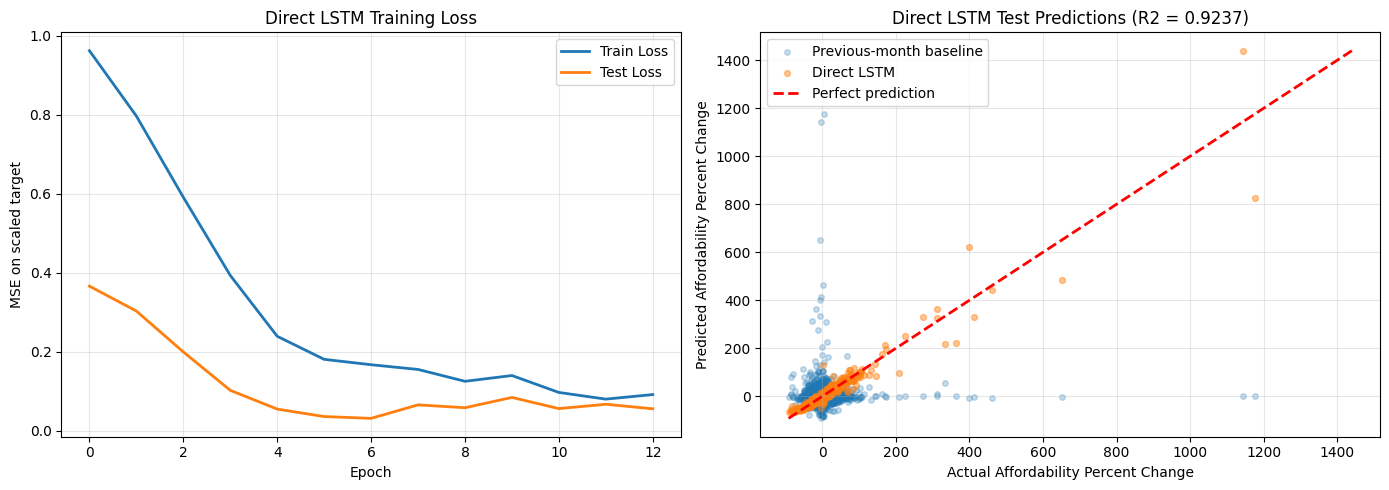

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(lstm_history.history['val_loss'], label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE on scaled target')
axes[0].set_title('Direct LSTM Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_lstm_test, y_lstm_test_baseline, alpha=0.25, s=16, label='Previous-month baseline')
axes[1].scatter(y_lstm_test, lstm_y_test_pred, alpha=0.45, s=18, label='Direct LSTM')
min_val = min(y_lstm_test.min(), lstm_y_test_pred.min(), y_lstm_test_baseline.min())
max_val = max(y_lstm_test.max(), lstm_y_test_pred.max(), y_lstm_test_baseline.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Affordability Percent Change')
axes[1].set_ylabel('Predicted Affordability Percent Change')
axes[1].set_title(f'Direct LSTM Test Predictions (R2 = {lstm_test_r2:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


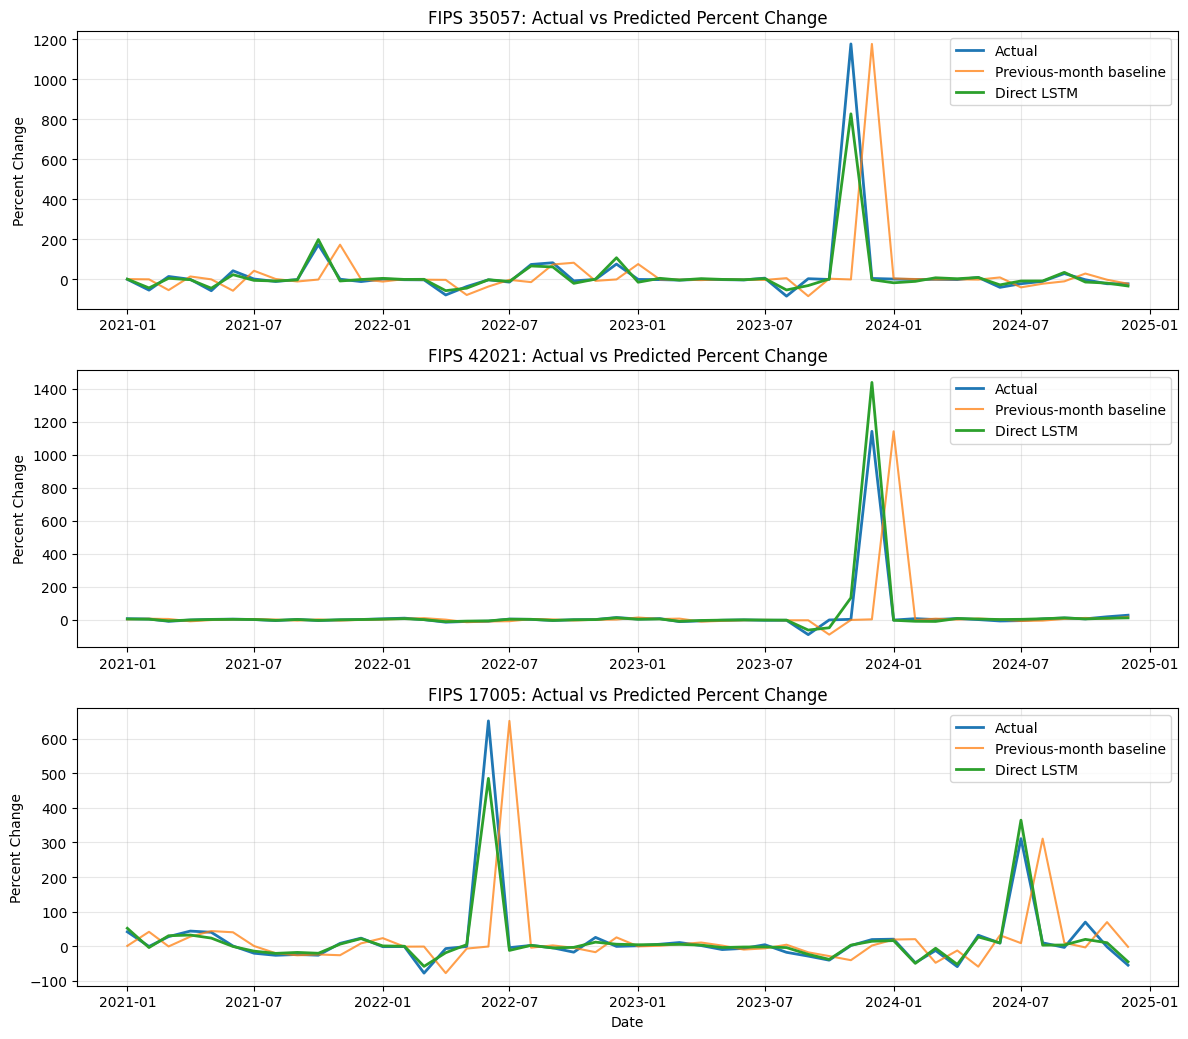

In [25]:
lstm_plot_df = lstm_test_df.copy()
lstm_plot_df['actual'] = y_lstm_test.reshape(-1)
lstm_plot_df['baseline'] = y_lstm_test_baseline.reshape(-1)
lstm_plot_df['predicted'] = lstm_y_test_pred.reshape(-1)

# Pick counties with high movement so the plot tests whether the model learned changes.
county_movement = lstm_plot_df.groupby('fips')['actual'].std().sort_values(ascending=False)
top_fips = county_movement.head(3).index.tolist()

fig, axes = plt.subplots(len(top_fips), 1, figsize=(12, 3.5 * len(top_fips)), sharex=False)
if len(top_fips) == 1:
    axes = [axes]

for ax, fips in zip(axes, top_fips):
    county = lstm_plot_df[lstm_plot_df['fips'] == fips].sort_values('date')
    ax.plot(county['date'], county['actual'], label='Actual', linewidth=2)
    ax.plot(county['date'], county['baseline'], label='Previous-month baseline', linewidth=1.5, alpha=0.75)
    ax.plot(county['date'], county['predicted'], label='Direct LSTM', linewidth=2)
    ax.set_title(f'FIPS {fips}: Actual vs Predicted Percent Change')
    ax.set_ylabel('Percent Change')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


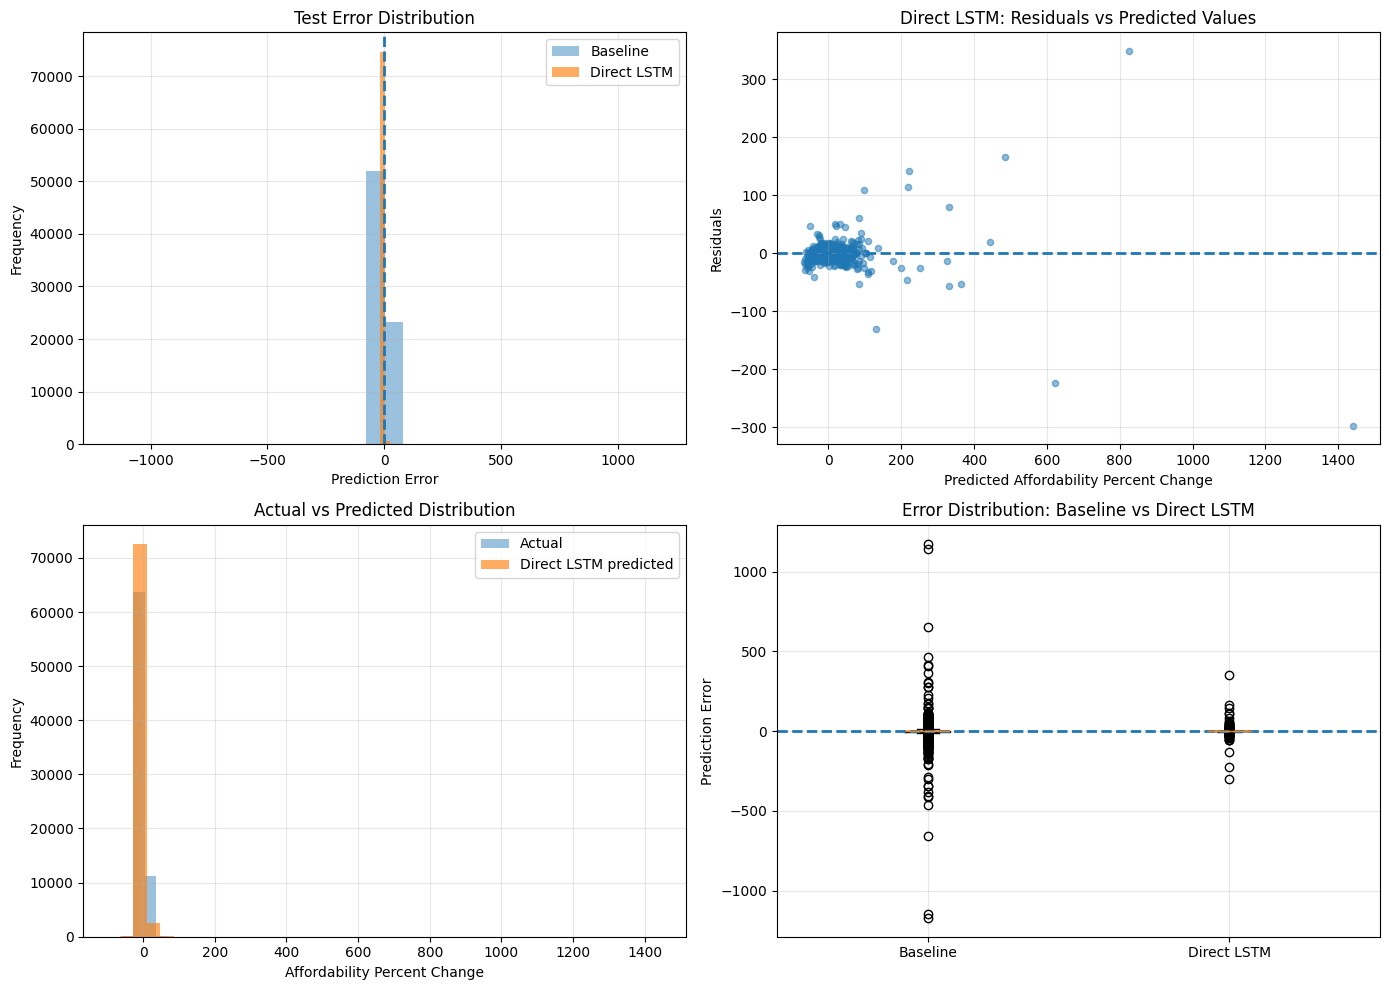

Direct LSTM Error Statistics:
Mean Error: 0.277342
Std Error: 2.792424
Min Error: -296.793091
Max Error: 349.037964
Prediction Std / Actual Std: 0.991


In [26]:
# Additional analysis: error distribution and anti-collapse diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

lstm_residuals = y_lstm_test.flatten() - lstm_y_test_pred.flatten()
baseline_residuals = y_lstm_test.flatten() - y_lstm_test_baseline.flatten()

axes[0, 0].hist(baseline_residuals, bins=30, alpha=0.45, label='Baseline')
axes[0, 0].hist(lstm_residuals, bins=30, alpha=0.65, label='Direct LSTM')
axes[0, 0].set_xlabel('Prediction Error')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Test Error Distribution')
axes[0, 0].axvline(x=0, linestyle='--', linewidth=2)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(lstm_y_test_pred, lstm_residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Affordability Percent Change')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Direct LSTM: Residuals vs Predicted Values')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(y_lstm_test.flatten(), bins=40, alpha=0.45, label='Actual')
axes[1, 0].hist(lstm_y_test_pred.flatten(), bins=40, alpha=0.65, label='Direct LSTM predicted')
axes[1, 0].set_xlabel('Affordability Percent Change')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Actual vs Predicted Distribution')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].boxplot([baseline_residuals, lstm_residuals], tick_labels=['Baseline', 'Direct LSTM'])
axes[1, 1].set_ylabel('Prediction Error')
axes[1, 1].set_title('Error Distribution: Baseline vs Direct LSTM')
axes[1, 1].axhline(y=0, linestyle='--', linewidth=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Direct LSTM Error Statistics:')
print(f'Mean Error: {np.mean(lstm_residuals):.6f}')
print(f'Std Error: {np.std(lstm_residuals):.6f}')
print(f'Min Error: {np.min(lstm_residuals):.6f}')
print(f'Max Error: {np.max(lstm_residuals):.6f}')
print(f'Prediction Std / Actual Std: {np.std(lstm_y_test_pred) / (np.std(y_lstm_test) + 1e-6):.3f}')
